In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#creating dataset
np.random.seed(23)

n = 2000

# Time series
timestamps = pd.date_range(
    start='2025-01-01',
    periods=n,
    freq='H'
)

df = pd.DataFrame({
    'Timestamp': timestamps.astype(str),
    'Heart_Rate': np.random.normal(75, 10, n),
    'Blood_Pressure_Systolic': np.random.normal(120, 15, n),
    'Blood_Pressure_Diastolic': np.random.normal(80, 10, n),
    'SpO2': np.random.normal(98, 1, n),
    'Temperature_C': np.random.normal(36.8, 0.3, n)
})

# Introducing realistic anomalies
anomaly_idx = np.random.choice(n, size=int(0.03*n), replace=False)

df.loc[anomaly_idx, 'Heart_Rate'] += np.random.choice([30, -25, 40], size=len(anomaly_idx))
df.loc[anomaly_idx, 'Blood_Pressure_Systolic'] += np.random.choice([40, -30, 50], size=len(anomaly_idx))
df.loc[anomaly_idx, 'Blood_Pressure_Diastolic'] += np.random.choice([20, -20, 30], size=len(anomaly_idx))
df.loc[anomaly_idx, 'SpO2'] -= np.random.choice([5, 8, 10], size=len(anomaly_idx))
df.loc[anomaly_idx, 'Temperature_C'] += np.random.choice([2.0, -2.5, 3.0], size=len(anomaly_idx))

# Introducing missing values
missing_rate = 0.05  # 5% missing

for col in df.columns[1:]:
    missing_idx = np.random.choice(n, size=int(missing_rate*n), replace=False)
    df.loc[missing_idx, col] = np.nan

# Adding sensor noise
df['Heart_Rate'] += np.random.normal(0, 2, n)
df['Blood_Pressure_Systolic'] += np.random.normal(0, 3, n)
df['Blood_Pressure_Diastolic'] += np.random.normal(0, 2, n)
df['SpO2'] += np.random.normal(0, 0.2, n)
df['Temperature_C'] += np.random.normal(0, 0.1, n)

# Cliping unrealistic physiological bounds
df['Heart_Rate'] = df['Heart_Rate'].clip(40, 180)
df['Blood_Pressure_Systolic'] = df['Blood_Pressure_Systolic'].clip(70, 220)
df['Blood_Pressure_Diastolic'] = df['Blood_Pressure_Diastolic'].clip(40, 140)
df['SpO2'] = df['SpO2'].clip(70, 100)
df['Temperature_C'] = df['Temperature_C'].clip(34, 42)

#Rounding values
df['Heart_Rate'] = np.round(df['Heart_Rate'])
df['Blood_Pressure_Systolic'] = np.round(df['Blood_Pressure_Systolic'])
df['Blood_Pressure_Diastolic'] = np.round(df['Blood_Pressure_Diastolic'])

df['SpO2'] = np.round(df['SpO2'], 0)
df['Temperature_C'] = np.round(df['Temperature_C'], 1)

df.head()

/tmp/ipykernel_2270/2804874882.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = pd.date_range(


,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,SpO2,Temperature_C
0,2025-01-01 00:00:00,80.0,138.0,62.0,99.0,36.3
1,2025-01-01 01:00:00,74.0,100.0,73.0,100.0,36.0
2,2025-01-01 02:00:00,67.0,NaN,79.0,99.0,NaN
3,2025-01-01 03:00:00,85.0,118.0,80.0,97.0,36.6
4,2025-01-01 04:00:00,80.0,132.0,69.0,98.0,36.7


**Data Preprocessing**

In [ ]:
#check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Timestamp                 2000 non-null   object 
 1   Heart_Rate                1900 non-null   float64
 2   Blood_Pressure_Systolic   1900 non-null   float64
 3   Blood_Pressure_Diastolic  1900 non-null   float64
 4   SpO2                      1900 non-null   float64
 5   Temperature_C             1900 non-null   float64
dtypes: float64(5), object(1)
memory usage: 93.9+ KB


In [ ]:
# Convert Timestamp to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Timestamp                 2000 non-null   datetime64[ns]
 1   Heart_Rate                1900 non-null   float64       
 2   Blood_Pressure_Systolic   1900 non-null   float64       
 3   Blood_Pressure_Diastolic  1900 non-null   float64       
 4   SpO2                      1900 non-null   float64       
 5   Temperature_C             1900 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 93.9 KB


In [ ]:
# Create Date column
df['Date'] = df['Timestamp'].dt.date

# Create Hour column
df['Hour'] = df['Timestamp'].dt.hour
df[['Timestamp','Date','Hour']].head()

,Timestamp,Date,Hour
0,2025-01-01 00:00:00,2025-01-01,0
1,2025-01-01 01:00:00,2025-01-01,1
2,2025-01-01 02:00:00,2025-01-01,2
3,2025-01-01 03:00:00,2025-01-01,3
4,2025-01-01 04:00:00,2025-01-01,4


In [ ]:
# Check missing values
df.isnull().sum()

,0
Timestamp,0
Heart_Rate,100
Blood_Pressure_Systolic,100
Blood_Pressure_Diastolic,100
SpO2,100
Temperature_C,100
Date,0
Hour,0


In [ ]:
# Applying time interpolation for handling missing values
df = df.sort_values('Timestamp')

df['Heart_Rate'] = df['Heart_Rate'].interpolate(method='linear')
df['Blood_Pressure_Systolic'] = df['Blood_Pressure_Systolic'].interpolate(method='linear')
df['Blood_Pressure_Diastolic'] = df['Blood_Pressure_Diastolic'].interpolate(method='linear')
df['SpO2'] = df['SpO2'].interpolate(method='linear')
df['Temperature_C'] = df['Temperature_C'].interpolate(method='linear')
#check again for missing values
df.isnull().sum()

,0
Timestamp,0
Heart_Rate,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0
SpO2,0
Temperature_C,0
Date,0
Hour,0


**Descriptive Statistics**

In [ ]:
# Select only health metric columns
cols = ['Heart_Rate', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'SpO2', 'Temperature_C']

# Compute statistics
summary = pd.DataFrame({
    'Mean': df[cols].mean(),
    'Median': df[cols].median(),
    'Min': df[cols].min(),
    'Max': df[cols].max(),
    'Std Dev': df[cols].std()
}).round(2)

summary

,Mean,Median,Min,Max,Std Dev
Heart_Rate,75.02,75.0,40.0,129.0,11.30
Blood_Pressure_Systolic,119.80,120.0,70.0,205.0,16.39
Blood_Pressure_Diastolic,80.41,80.0,40.0,135.0,10.61
SpO2,97.75,98.0,86.0,100.0,1.76
Temperature_C,36.81,36.8,34.0,40.4,0.53


In [ ]:
# Define physiological thresholds
conditions = (
    (df['Heart_Rate'] > 120) | (df['Heart_Rate'] < 50) |
    (df['Blood_Pressure_Systolic'] > 180) |
    (df['Blood_Pressure_Diastolic'] > 110) |
    (df['SpO2'] < 92) |
    (df['Temperature_C'] > 38.5) | (df['Temperature_C'] < 35)
)

# Flag anomalies
df['Anomaly'] = conditions.astype(int)

# Show anomalies
anomalies = df[df['Anomaly'] == 1]
anomalies.head()



,Timestamp,Heart_Rate,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,SpO2,Temperature_C,Date,Hour,Anomaly
13,2025-01-01 13:00:00,50.0,175.0,48.0,91.0,39.8,2025-01-01,13,1
36,2025-01-02 12:00:00,49.0,119.5,87.0,97.0,36.6,2025-01-02,12,1
60,2025-01-03 12:00:00,53.0,155.0,101.0,87.0,39.7,2025-01-03,12,1
61,2025-01-03 13:00:00,44.0,144.0,54.0,89.0,39.5,2025-01-03,13,1
116,2025-01-05 20:00:00,119.0,70.0,56.0,91.0,34.2,2025-01-05,20,1


In [ ]:
df['Anomaly'].value_counts()

,count
Anomaly,
0,1933
1,67


**Visualization**

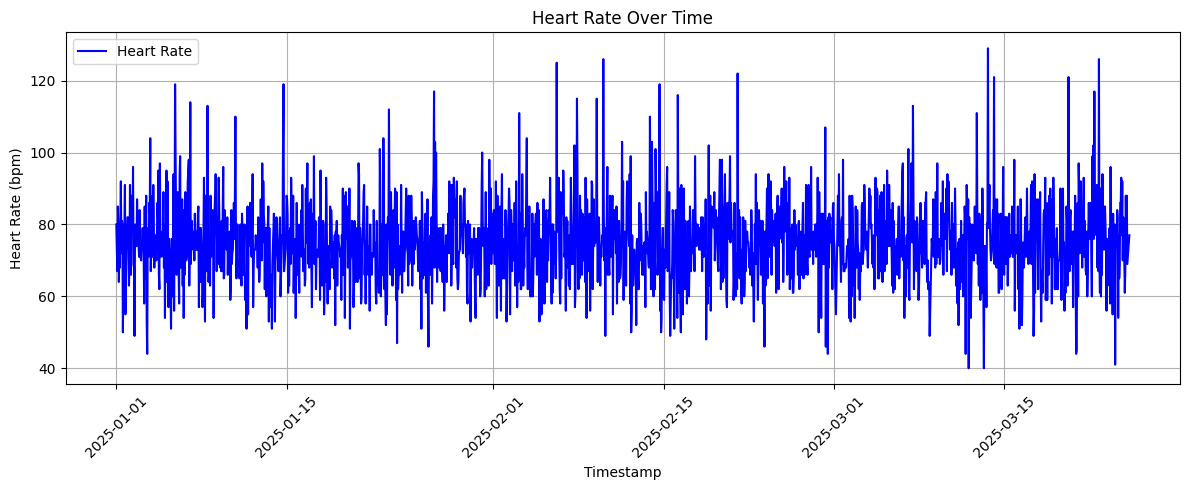

In [ ]:
#Heart Rate Over Time
plt.figure(figsize=(12, 5))
plt.plot(df['Timestamp'], df['Heart_Rate'], label='Heart Rate', color='blue')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

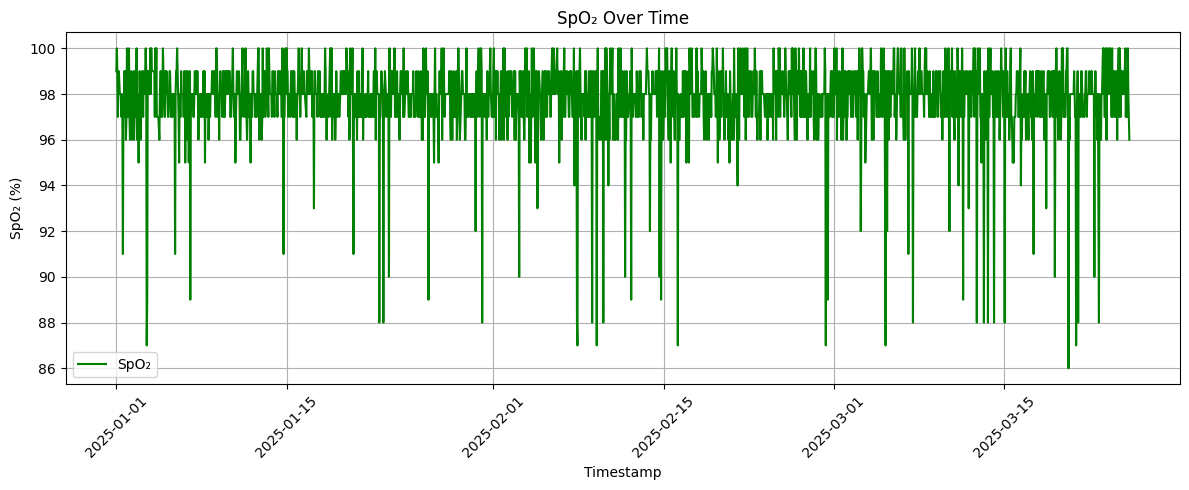

In [ ]:
#SpO₂ Over Time
plt.figure(figsize=(12, 5))
plt.plot(df['Timestamp'], df['SpO2'], label='SpO₂', color='green')
plt.xlabel('Timestamp')
plt.ylabel('SpO₂ (%)')
plt.title('SpO₂ Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

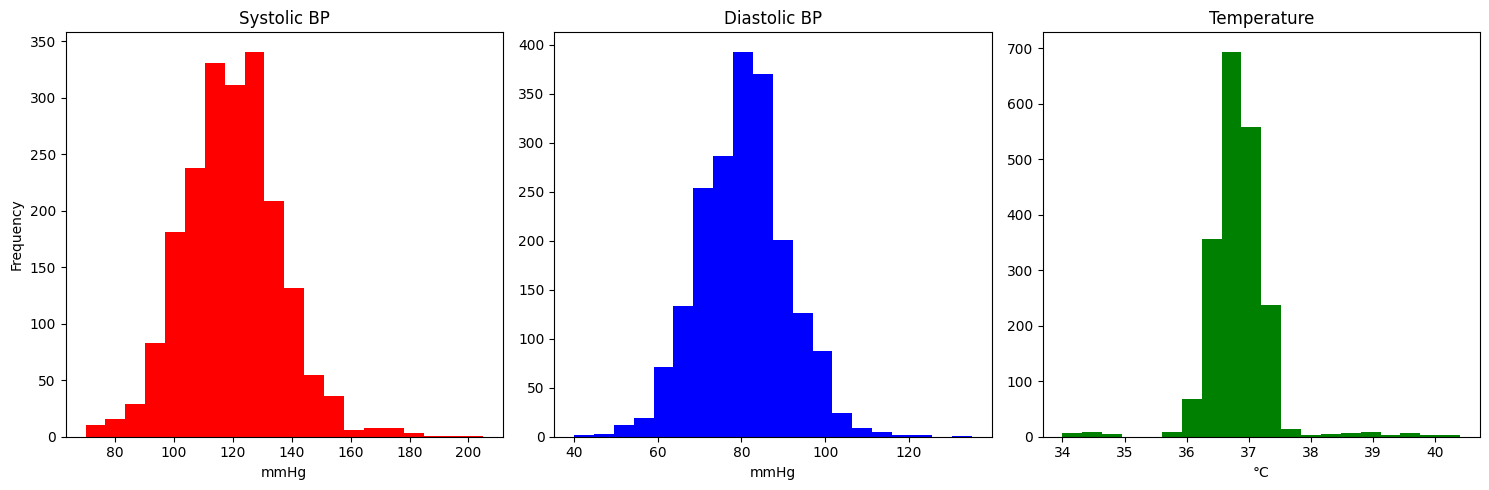

In [ ]:
#Creating histograms for blood pressure and temperatures
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].hist(df['Blood_Pressure_Systolic'], bins=20, color='red')
axes[0].set_title('Systolic BP')
axes[0].set_xlabel('mmHg')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Blood_Pressure_Diastolic'], bins=20, color='blue')
axes[1].set_title('Diastolic BP')
axes[1].set_xlabel('mmHg')

axes[2].hist(df['Temperature_C'], bins=20, color='green')
axes[2].set_title('Temperature')
axes[2].set_xlabel('°C')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2270/1079500434.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


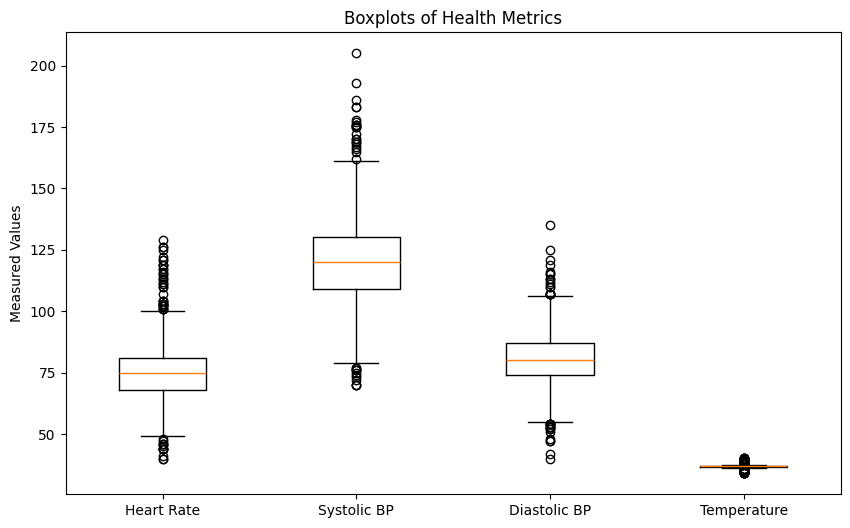

In [ ]:
from matplotlib import axis
#Create boxplots for heart rate, blood pressure, and temperature
plt.figure(figsize=(10,6))

plt.boxplot([
    df['Heart_Rate'].dropna(),
    df['Blood_Pressure_Systolic'].dropna(),
    df['Blood_Pressure_Diastolic'].dropna(),
    df['Temperature_C'].dropna()
],
labels=[
    'Heart Rate',
    'Systolic BP',
    'Diastolic BP',
    'Temperature'
])

plt.title('Boxplots of Health Metrics')
plt.ylabel('Measured Values')
plt.show()

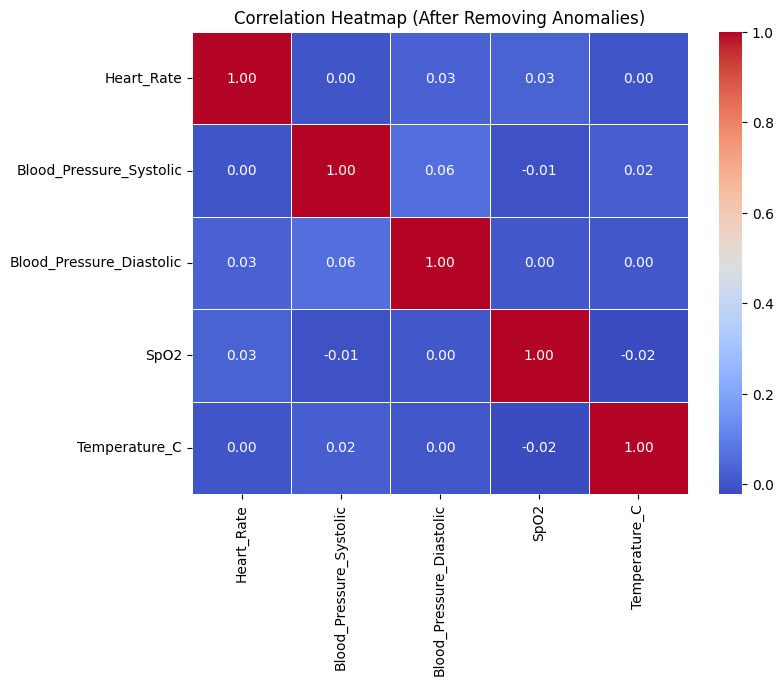

In [ ]:
#Correlation heatmap between all health metrics
df_clean = df[df['Anomaly'] == 0]
corr_matrix = df_clean[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (After Removing Anomalies)")
plt.show()

**Advanced Analysis**

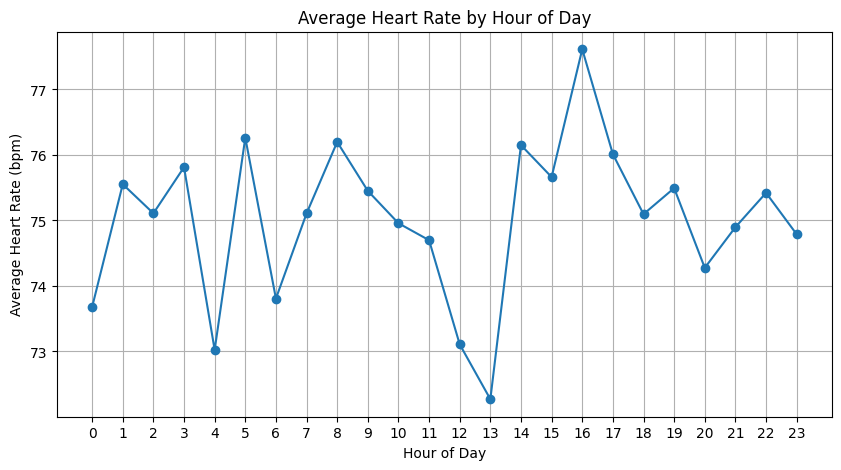

In [ ]:
#Average heart rate by hour
hourly_hr = df.groupby('Hour')['Heart_Rate'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_hr.index, hourly_hr.values, marker='o')
plt.title('Average Heart Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Heart Rate (bpm)')
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

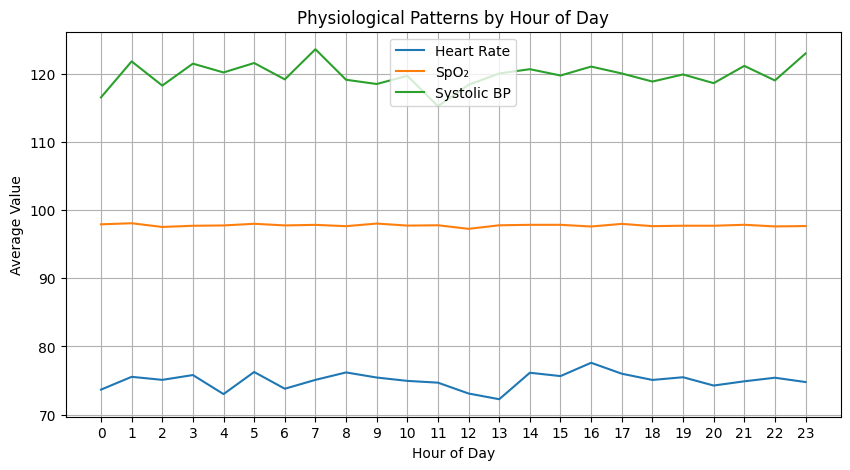

In [ ]:
# Computing hourly average trends for key physiological signals
hourly_spo2 = df.groupby('Hour')['SpO2'].mean()
hourly_sys = df.groupby('Hour')['Blood_Pressure_Systolic'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_hr.index, hourly_hr.values, label='Heart Rate')
plt.plot(hourly_spo2.index, hourly_spo2.values, label='SpO₂')
plt.plot(hourly_sys.index, hourly_sys.values, label='Systolic BP')
plt.title('Physiological Patterns by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Value')
plt.legend()
plt.grid(True)
plt.xticks(range(0,24))
plt.show()

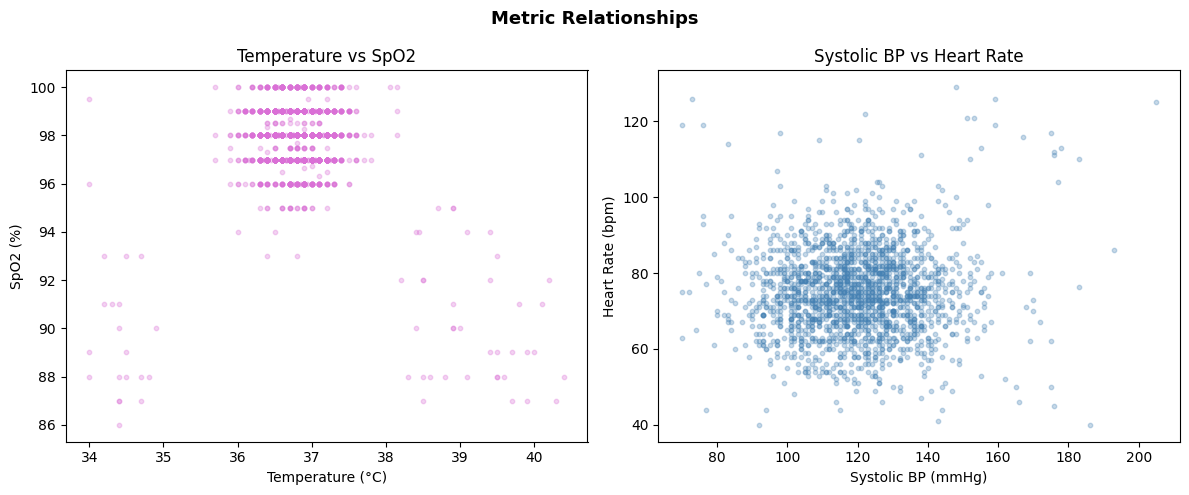

In [ ]:
#Relationships between metrics

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Metric Relationships",fontsize=13, fontweight="bold")

# Temperature vs SpO2
axes[0].scatter(df["Temperature_C"], df["SpO2"],
                alpha=0.3, s=10, color="orchid")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("SpO2 (%)")
axes[0].set_title("Temperature vs SpO2")

# Systolic BP vs Heart Rate
axes[1].scatter(df["Blood_Pressure_Systolic"], df["Heart_Rate"],
                alpha=0.3, s=10, color="steelblue")
axes[1].set_xlabel("Systolic BP (mmHg)")
axes[1].set_ylabel("Heart Rate (bpm)")
axes[1].set_title("Systolic BP vs Heart Rate")

plt.tight_layout()
plt.savefig("fig7_scatter_relationships.png", bbox_inches="tight")
plt.show()